Cargando paquete requerido: S4Vectors

Cargando paquete requerido: stats4

Cargando paquete requerido: BiocGenerics

Cargando paquete requerido: generics


Adjuntando el paquete: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Adjuntando el paquete: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Adjuntando el paquete: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    fin

# A tibble: 3 × 2
  regulation            n
  <chr>             <int>
1 No significativo 109784
2 Sobreexpresado     5319
3 Subexpresado       5949


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,regulation
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
pelegrina_gene1000164_i1,8.095509,2.633586,0.8881379,2.965289,3.023984e-03,1.316287e-02,Sobreexpresado
pelegrina_gene1000352_i1,8.101986,-6.147204,1.3707848,-4.484441,7.310526e-06,5.592479e-05,Subexpresado
pelegrina_gene100087_i1,4.621641,6.043667,1.5657398,3.859943,1.134133e-04,6.961567e-04,Sobreexpresado
pelegrina_gene1000884_i1,6.065661,4.634688,1.3117450,3.533223,4.105258e-04,2.235089e-03,Sobreexpresado
pelegrina_gene1001932_i1,10.666785,-3.353005,0.7584766,-4.420710,9.837698e-06,7.368808e-05,Subexpresado
pelegrina_gene1002105_i1,20.205954,2.397962,0.5785516,4.144767,3.401595e-05,2.310977e-04,Sobreexpresado



out of 121085 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 18891, 16%
LFC < 0 (down)     : 20957, 17%
outliers [1]       : 33, 0.027%
low counts [2]     : 0, 0%
(mean count < 2)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



[1] 11268

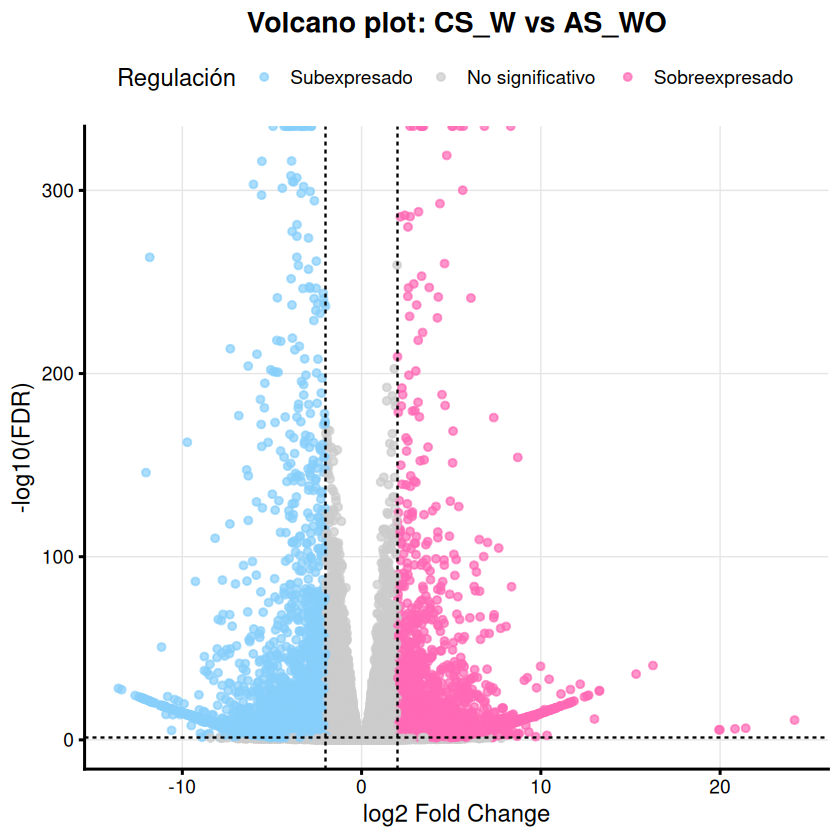



clusterProfiler v4.16.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Adjuntando el paquete: ‘clusterProfiler’


The following object is masked from ‘package:IRanges’:

    slice


The following object is masked from ‘package:S4Vectors’:

    rename


The following object is masked from ‘package:stats’:

    filter


enrichplot v1.28.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, and Qing-Yu He. ChIPseeker: an
R/Bioconductor package for ChIP peak annotation, comparison and
visualization. Bioinformatics. 2015, 31(14):2382-2383


Adjuntando el paquete: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




Genes fondo: 44035 
DEGs: 11268 
DEGs con KEGG: 604 
               ID                             Description Count GeneRatio
map00940 map00940            Phenylpropanoid biosynthesis    23    23/604
map05322 map05322            Systemic lupus erythematosus    28    28/604
map00073 map00073    Cutin, suberine and wax biosynthesis    12    12/604
map03030 map03030                         DNA replication    19    19/604
map00062 map00062                   Fatty acid elongation    12    12/604
map05202 map05202 Transcriptional misregulation in cancer    11    11/604
map03460 map03460                  Fanconi anemia pathway     9     9/604
map02010 map02010                        ABC transporters     8     8/604
map04923 map04923   Regulation of lipolysis in adipocytes     3     3/604
             p.adjust
map00940 2.857215e-10
map05322 1.110846e-08
map00073 9.274532e-08
map03030 2.876847e-06
map00062 9.825724e-05
map05202 1.866536e-03
map03460 3.574046e-02
map02010 3.574046e-02
map04923 

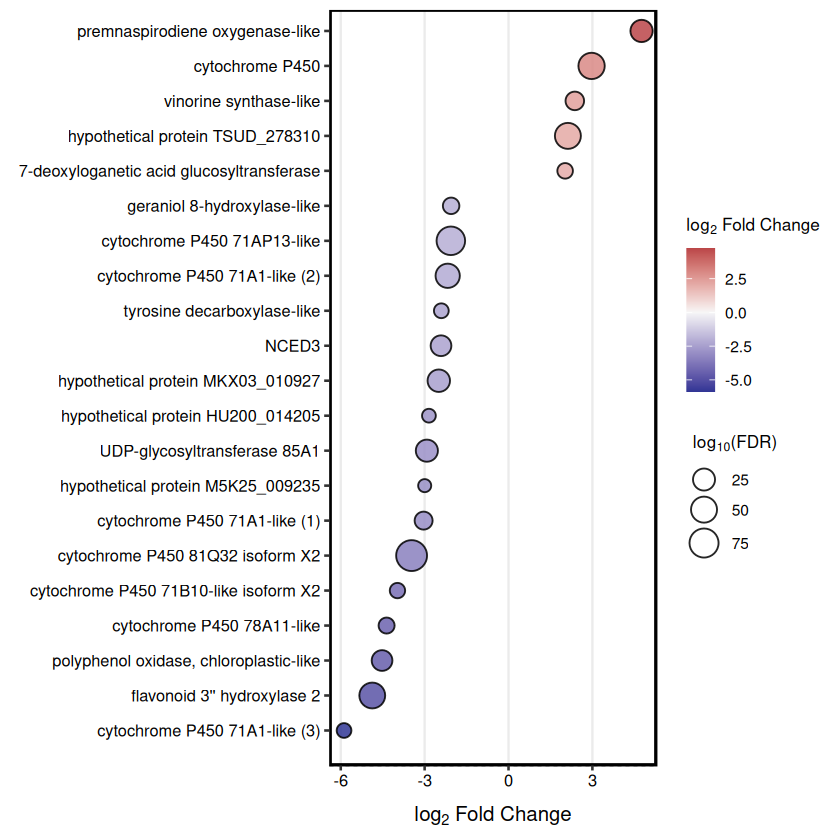

In [ ]:
###########################################################
# CS_W_VS_AS_WO logFC=2
###########################################################

setwd("/home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA")

library(tximport)
library(DESeq2)
library(dplyr)
library(ggplot2)


# ===============================
# 1. Muestras
# ===============================
samples <- c(
  "AS_WO_R1","AS_WO_R2","AS_WO_R3",
  "AS_W_R1","AS_W_R2","AS_W_R3",
  "CS_W_R1","CS_W_R2","CS_W_R3"
)

files <- file.path("Counts_2", paste0(samples, ".sf"))
names(files) <- samples

# ===============================
# 2. Importación
# ===============================
txi <- tximport(
  files,
  type = "salmon",
  txOut = TRUE,
  importer = function(x) {
    read.delim(x, check.names = FALSE) %>%
      arrange(Name)
  }
)

# ===============================
# 3. Metadata
# ===============================
coldata <- data.frame(
  row.names = samples,
  condition = c(
    "AS_WO","AS_WO","AS_WO",
    "AS_W","AS_W","AS_W",
    "CS_W","CS_W","CS_W"
  )
)

coldata$condition <- factor(
  coldata$condition,
  levels = c("AS_WO", "AS_W", "CS_W")
)

# ===============================
# 4. DESeq2
# ===============================
dds <- DESeqDataSetFromTximport(
  txi,
  colData = coldata,
  design = ~ condition
)

dds <- dds[rowSums(counts(dds) >= 5) >= 3, ]
dds <- DESeq(dds)

# ===============================
# 5. RESULTADOS
# ===============================
res_CSW_vs_ASWO <- results(
  dds,
  contrast = c("condition", "CS_W", "AS_WO")
)

# ===============================
# 6. Dataframe base
# ===============================
res_df <- as.data.frame(res_CSW_vs_ASWO)

# ===============================
# 7. Parámetros
# ===============================
lfc_cutoff <- 2
padj_cutoff <- 0.05

# ===============================
# 8. Dataframe para plot
# ===============================
res_plot <- res_df %>%
  filter(!is.na(padj)) %>%
  mutate(regulation = case_when(
    padj < padj_cutoff & log2FoldChange >= lfc_cutoff  ~ "Sobreexpresado",
    padj < padj_cutoff & log2FoldChange <= -lfc_cutoff ~ "Subexpresado",
    TRUE ~ "No significativo"
  ))

# ===============================
# 9. Conteo
# ===============================
conteo_genes <- res_plot %>%
  group_by(regulation) %>%
  summarise(n = n())

print(conteo_genes)

# ===============================
# 10. Orden factor
# ===============================
res_plot$regulation <- factor(
  res_plot$regulation,
  levels = c("Subexpresado", "No significativo", "Sobreexpresado")
)

# ===============================
# 11. Dataframe filtrado (DEG)
# ===============================
res_filtrado <- res_plot %>%
  filter(
    padj < padj_cutoff,
    abs(log2FoldChange) >= lfc_cutoff
  )

# ===============================
# 12. Output
# ===============================
head(res_filtrado)
summary(res_CSW_vs_ASWO)
nrow(res_filtrado)

write.csv(res_filtrado, "DEG_CSW_vs_ASWOlogFC2.csv")

# ===============================
# 13. Volcano plot
# ===============================
p1 <- ggplot(res_plot, aes(x = log2FoldChange, y = -log10(padj))) +
  geom_point(aes(color = regulation), alpha = 0.7, size = 1.5) +
  geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff),
             linetype = "dashed", linewidth = 0.5) +
  geom_hline(yintercept = -log10(padj_cutoff),
             linetype = "dashed", linewidth = 0.5) +
  scale_color_manual(values = c(
    "Subexpresado" = "#87CEFA",
    "No significativo" = "grey80",
    "Sobreexpresado" = "#FF69B4"
  )) +
  labs(
    title = "Volcano plot: CS_W vs AS_WO",
    x = "log2 Fold Change",
    y = "-log10(FDR)",
    color = "Regulación"
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "top",
    plot.title = element_text(face = "bold", hjust = 0.5),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
    panel.grid.minor = element_blank()
  )
print(p1)

ggsave(
  filename = "Volcano_CSW_vs_ASWOlogFC2.png",
  plot = p1,
  width = 10,
  height = 8,
  dpi = 300
)

# Genes de interés
# ===============================
genes_interes <- c(
  "pelegrina_gene1170725_i2",
  "pelegrina_gene162036_i1",
  "pelegrina_gene1037623_i3",
  "pelegrina_gene1904850_i1",
  "pelegrina_gene1748183_i1",
  "pelegrina_gene1463574_i8",
  "pelegrina_gene843791_i2",
  "pelegrina_gene1452632_i3",
  "pelegrina_gene1313581_i1",
  "pelegrina_gene1478299_i1",
  "pelegrina_gene1172636_i8",
  "pelegrina_gene1412731_i1",
  "pelegrina_gene1524_i4",
  "pelegrina_gene1911193_i2",
  "pelegrina_gene846247_i2",  
  "pelegrina_gene835130_i1",
  "pelegrina_gene15924_i6",
  "pelegrina_gene1047824_i3",
  "pelegrina_gene1061014_i1",
  "pelegrina_gene1314155_i6",
  "pelegrina_gene1317880_i1"  
)




# ===============================
# Descripciones
# ===============================
descripciones <- data.frame(
  gene = c(
  "pelegrina_gene1170725_i2",
  "pelegrina_gene162036_i1",
  "pelegrina_gene1037623_i3",
  "pelegrina_gene1904850_i1",
  "pelegrina_gene1748183_i1",
  "pelegrina_gene1463574_i8",
  "pelegrina_gene843791_i2",
  "pelegrina_gene1452632_i3",
  "pelegrina_gene1313581_i1",
  "pelegrina_gene1478299_i1",
  "pelegrina_gene1172636_i8",
  "pelegrina_gene1412731_i1",
  "pelegrina_gene1524_i4",
  "pelegrina_gene1911193_i2",
  "pelegrina_gene846247_i2",  
  "pelegrina_gene835130_i1",
  "pelegrina_gene15924_i6",
  "pelegrina_gene1047824_i3",
  "pelegrina_gene1061014_i1",
  "pelegrina_gene1314155_i6",
  "pelegrina_gene1317880_i1" 
    #"pelegrina_gene1733372_i3"
  ),
  descripcion = c(
    "UDP-glycosyltransferase 85A1 [Apostasia shenzhenica]",
    "cytochrome P450 71A1-like [Zingiber officinale].",
    "polyphenol oxidase, chloroplastic-like [Typha latifolia].",
    "vinorine synthase-like [Papaver somniferum].",
    "tyrosine decarboxylase-like [Magnolia sinica].",
    "hypothetical protein M5K25_009235 [Dendrobium thyrsiflorum]",
    "7-deoxyloganetic acid glucosyltransferase [Beta vulgaris subsp.Vulgaris].",
    "cytochrome P450 71B10-like isoform X2 [Telopea speciosissima].",
    "flavonoid 3'' hydroxylase 2 [Euphorbia maculata].",
    "cytochrome P450 78A11-like [Typha latifolia].",
    "cytochrome P450 [Musa troglodytarum]",
    "cytochrome P450 71A1-like [Phoenix dactylifera].",
    "geraniol 8-hydroxylase-like [Triticum aestivum].",
    "cytochrome P450 71AP13-like [Dioscorea cayenensis subsp.  Rotundata].",
    "cytochrome P450 81Q32 isoform X2 [Ziziphus jujuba].",
    "premnaspirodiene oxygenase-like [Phoenix dactylifera].",
    "hypothetical protein HU200_014205 [Digitaria exilis]",
    "NCED3 [Lilium davidii].",
    "hypothetical protein MKX03_010927 [Papaver bracteatum]",
    "cytochrome P450 71A1-like [Dendrobium catenatum].",
    "hypothetical protein TSUD_278310 [Trifolium subterraneum]" 
    #"protein LEO1 homolog isoform X1 [Phoenix dactylifera]."
    
  )
)
# ==============================================================================
# Limpieza de Descripciones (Solo nombre de la función)
# ==============================================================================
descripciones$descripcion_limpia <- sub("\\s*\\[.*\\]", "", descripciones$descripcion)
descripciones$descripcion_limpia <- sub("\\.$", "", descripciones$descripcion_limpia)

# ==============================================================================
# Subset resultados y agregar descripciones
# ==============================================================================
subset_res <- res_df[rownames(res_df) %in% genes_interes, ]
subset_res$gene <- rownames(subset_res)

subset_res <- merge(
  subset_res,
  descripciones,
  by = "gene"
)

subset_res <- subset_res %>%
  filter(!is.na(padj), padj > 0)


subset_res <- subset_res %>%
  group_by(descripcion_limpia) %>%
  mutate(
    descripcion_grafico = if(n() > 1) {
      paste0(descripcion_limpia, " (", row_number(), ")")
    } else {
      descripcion_limpia
    }
  ) %>%
  ungroup()

# ==============================================================================
# Ordenar dataframe y asignar etiquetas únicas
# ==============================================================================
# Ordenamos por log2FoldChange de menor a mayor
subset_res <- subset_res[order(subset_res$log2FoldChange), ]

subset_res$label <- factor(
  subset_res$descripcion_grafico, 
  levels = subset_res$descripcion_grafico
)

# ==============================================================================
# Bubble plot
# ==============================================================================
p2 <- ggplot(
  subset_res,
  aes(
    x = label,          
    y = log2FoldChange,
    fill = log2FoldChange,  
    size = -log10(padj)
  )
) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray60", linewidth = 0.4) +
  geom_point(shape = 21, color = "black", alpha = 0.85, stroke = 0.6) +
  coord_flip() +
  
  scale_fill_gradient2(
    low = "#313695",     
    mid = "#f7f7f7",     
    high = "#a50026",    
    midpoint = 0,
    name = expression(log[2] * " Fold Change")
  ) +
  
  scale_size_continuous(
    range = c(3, 8), 
    name = expression(-log[10] * "(FDR)")
  ) +
  
  labs(
    x = NULL, 
    y = expression(log[2] * " Fold Change")
  ) +
  
  theme_bw(base_size = 12) +
  theme(
    panel.grid.major.x = element_line(color = "gray92", linewidth = 0.5),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    
    axis.text.x = element_text(color = "black"),
    axis.text.y = element_text(color = "black", size = 9.5), 
    axis.title.x = element_text(face = "bold", margin = margin(t = 10)),
    
    legend.position = "right",
    legend.title = element_text(size = 10, face = "bold"),
    legend.text = element_text(size = 9),
    legend.background = element_blank(),
    legend.box.background = element_blank()
  )

ggsave(
  filename = "BubblePlot_pigment_genes_clean_fixed.pdf",
  plot = p2,
  width = 10,
  height = 7,  
  useDingbats = FALSE
)

print(p2)

# ===============================
# KEGG ENRICHMENT
# ===============================

library(clusterProfiler)
library(enrichplot)
library(tidyr)

# ===============================
# KO -> Pathway
# ===============================

ko2path <- read.delim(
  "ko2pathway.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(ko2path) <- c(
  "KO",
  "Pathway"
)

ko2path$KO <- sub("^ko:", "", ko2path$KO)
ko2path$Pathway <- sub("^path:", "", ko2path$Pathway)

# ===============================
# Gene -> KO
# ===============================

ko_gene <- read.delim(
  "KO.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(ko_gene) <- c(
  "gene",
  "KO"
)

ko_gene$gene <- sub(
  "\\.p[0-9]+$",
  "",
  ko_gene$gene
)

# ===============================
# Gene -> Pathway
# ===============================

gene2path <- merge(
  ko_gene,
  ko2path,
  by = "KO"
)

gene2path$Pathway <- sub(
  "^ko",
  "map",
  gene2path$Pathway
)

gene2path <- gene2path %>%
  distinct(
    gene,
    Pathway,
    .keep_all = TRUE
  )

# ===============================
# Nombres pathways
# ===============================

pathway_names <- read.delim(
  "pathway_names.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(pathway_names) <- c(
  "Pathway",
  "Description"
)

pathway_names$Pathway <- sub(
  "^path:",
  "",
  pathway_names$Pathway
)

# ===============================
# TERM2GENE
# ===============================

TERM2GENE <- gene2path %>%
  select(
    Pathway,
    gene
  ) %>%
  distinct()

# eliminar pathways muy pequeños

TERM2GENE <- TERM2GENE %>%
  group_by(Pathway) %>%
  filter(n() >= 5) %>%
  ungroup()

# ===============================
# TERM2NAME
# ===============================

TERM2NAME <- pathway_names %>%
  select(
    Pathway,
    Description
  ) %>%
  distinct()

# ===============================
# Universo
# ===============================

background_genes <- unique(
  TERM2GENE$gene
)

# ===============================
# DEGs
# ===============================

deg_genes <- rownames(
  res_filtrado
)

deg_genes_kegg <- intersect(
  deg_genes,
  background_genes
)

cat(
  "Genes fondo:",
  length(background_genes),
  "\n"
)

cat(
  "DEGs:",
  length(deg_genes),
  "\n"
)

cat(
  "DEGs con KEGG:",
  length(deg_genes_kegg),
  "\n"
)

# ===============================
# Enrichment
# ===============================

kegg_enrich <- enricher(
  gene = deg_genes_kegg,
  universe = background_genes,
  TERM2GENE = TERM2GENE,
  TERM2NAME = TERM2NAME,
  pAdjustMethod = "BH",
  pvalueCutoff = 0.05,
  qvalueCutoff = 0.20
)

if(is.null(kegg_enrich)){
  stop("No se encontraron pathways enriquecidos")
}

kegg_res <- as.data.frame(
  kegg_enrich
)

if(nrow(kegg_res) == 0){
  stop("No se encontraron pathways enriquecidos")
}

# ===============================
# Eliminar rutas generales
# ===============================

rutas_generales <- c(
  "Metabolic pathways",
  "Biosynthesis of secondary metabolites",
  "Biosynthesis of cofactors",
  "Microbial metabolism in diverse environments"
)

kegg_res <- kegg_res %>%
  filter(
    !Description %in% rutas_generales
  )

# actualizar objeto enrichResult

kegg_enrich@result <- kegg_enrich@result %>%
  filter(
    !Description %in% rutas_generales
  )

# ===============================
# Ordenar
# ===============================

kegg_res <- kegg_res %>%
  arrange(
    p.adjust
  )

# ===============================
# Guardar tabla
# ===============================

write.csv(
  kegg_res,
  "KEGG_Enrichment_CSW_vs_ASWO_FINAL_logFC2.csv",
  row.names = FALSE
)

print(
  kegg_res[, c(
    "ID",
    "Description",
    "Count",
    "GeneRatio",
    "p.adjust"
  )]
)

# ===============================
# Genes por pathway
# ===============================

pathway_genes <- kegg_res %>%
  select(
    ID,
    Description,
    geneID
  )

pathway_genes_expanded <- pathway_genes %>%
  separate_rows(
    geneID,
    sep = "/"
  )

colnames(
  pathway_genes_expanded
)[3] <- "gene"

res_export <- res_df
res_export$gene <- rownames(res_export)

pathway_genes_expanded <- merge(
  pathway_genes_expanded,
  res_export[, c(
    "gene",
    "log2FoldChange",
    "padj"
  )],
  by = "gene",
  all.x = TRUE
)

pathway_genes_expanded$regulation <- ifelse(
  pathway_genes_expanded$log2FoldChange > 0,
  "Sobreexpresado",
  "Subexpresado"
)

pathway_genes_expanded <- pathway_genes_expanded %>%
  arrange(
    Description,
    desc(abs(log2FoldChange))
  )

write.csv(
  pathway_genes_expanded,
  "KEGG_Pathway_Gene_Details_CSW_vs_ASWO_logFC2.csv",
  row.names = FALSE
)

# ===============================
# Barplot
# ===============================

top_kegg <- kegg_res %>%
  arrange(p.adjust) %>%
  slice_head(
    n = min(
      15,
      nrow(kegg_res)
    )
  )

top_kegg$Description <- factor(
  top_kegg$Description,
  levels = rev(
    top_kegg$Description
  )
)

p_kegg_bar <- ggplot(
  top_kegg,
  aes(
    x = Description,
    y = Count,
    fill = -log10(p.adjust)
  )
) +
  geom_col() +
  coord_flip() +
  theme_bw(base_size = 14)

ggsave(
  "KEGG_Barplot_CSW_vs_ASWO_logFC2.png",
  p_kegg_bar,
  width = 10,
  height = 7,
  dpi = 300
)

# ===============================
# Bubble plot
# ===============================

top_kegg <- kegg_res %>%
  arrange(p.adjust) %>%
  slice_head(
    n = min(
      20,
      nrow(kegg_res)
    )
  )

top_kegg$GeneRatioNum <- sapply(
  strsplit(
    top_kegg$GeneRatio,
    "/"
  ),
  function(x)
    as.numeric(x[1]) /
    as.numeric(x[2])
)

p_kegg_bubble <- ggplot(
  top_kegg,
  aes(
    x = GeneRatioNum,
    y = reorder(
      Description,
      GeneRatioNum
    )
  )
) +
  geom_point(
    aes(
      size = Count,
      color = -log10(p.adjust)
    )
  ) +
  theme_bw(base_size = 14)

ggsave(
  "KEGG_Bubble_CSW_vs_ASWO_logFC2.png",
  p_kegg_bubble,
  width = 10,
  height = 7,
  dpi = 300
)

# ===============================
# Dotplot
# ===============================

p_dot <- dotplot(
  kegg_enrich,
  showCategory = min(
    20,
    nrow(kegg_enrich@result)
  )
)

ggsave(
  "KEGG_Dotplot_CSW_vs_ASWO_logFC2.png",
  p_dot,
  width = 10,
  height = 7,
  dpi = 300
)

# ===============================
# Exportar genes por pathway
# ===============================

write.csv(
  pathway_genes_expanded,
  "KEGG_Pathway_Gene_Details_CSW_vs_ASWO_logFC2.csv",
  row.names = FALSE
)

write.csv(
  kegg_res[, c(
    "Description",
    "Count",
    "geneID"
  )],
  "KEGG_Pathways_with_Genes_CSW_vs_ASWO_logFC2.csv",
  row.names = FALSE
)

# ===============================
# Resumen por pathway
# ===============================

pathway_summary <- pathway_genes_expanded %>%
  group_by(
    Description
  ) %>%
  summarise(
    n_genes = n(),
    mean_log2FC = mean(
      log2FoldChange,
      na.rm = TRUE
    ),
    median_log2FC = median(
      log2FoldChange,
      na.rm = TRUE
    )
  )

write.csv(
  pathway_summary,
  "KEGG_Pathway_Summary_CSW_vs_ASWO_logFC2.csv",
  row.names = FALSE
)




##############################################################################
Pathview is an open source software package distributed under GNU General
Public License version 3 (GPLv3). Details of GPLv3 is available at
http://www.gnu.org/licenses/gpl-3.0.html. Particullary, users are required to
formally cite the original Pathview paper (not just mention it) in publications
or products. For details, do citation("pathview") within R.

The pathview downloads and uses KEGG data. Non-academic uses may require a KEGG
license agreement (details at http://www.kegg.jp/kegg/legal.html).
##############################################################################



Número de KO en map00940: 15 
Número de genes asociados: 158 

Top genes de Phenylpropanoid biosynthesis
                       gene     KO     logFC
1   pelegrina_gene990635_i1 K00430 -5.629076
2  pelegrina_gene1784276_i3 K00430 -4.863465
3    pelegrina_gene26594_i1 K18368 -4.471461
4  pelegrina_gene1723302_i2 K00430 -4.216863
5  pelegrina_gene1914102_i1 K00430  4.017827
6  pelegrina_gene1963251_i7 K00430 -3.908104
7  pelegrina_gene1040488_i1 K00430  3.876944
8  pelegrina_gene1936754_i1 K12355  3.789995
9     pelegrina_gene6267_i1 K00430 -3.691636
10 pelegrina_gene1043531_i2 K09753 -3.426949
11 pelegrina_gene1942788_i1 K18368 -3.426861
12 pelegrina_gene1312472_i5 K13065  3.361636
13 pelegrina_gene1510025_i1 K13066 -3.090138
14 pelegrina_gene1036419_i1 K00430 -2.989409
15  pelegrina_gene867064_i2 K00430 -2.957757
16  pelegrina_gene16189_i16 K00430  2.918502
17    pelegrina_gene2309_i1 K00083  2.819003
18 pelegrina_gene1725145_i5 K00430 -2.784182
19  pelegrina_gene598147_i1 K00430 -2.59

Note: Only KEGG ortholog gene ID is supported, make sure it looks like "K01488"!

Note: Mapping via KEGG gene ID (not Entrez) is supported for this species,
it looks like "K01488"!

Info: Working in directory /home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA

Info: Writing image file ko00940.pathview.png



[1] TRUE

KO,n
<chr>,<int>
K00430,78
K09753,21
K01904,17
K00083,10
K18368,9
K13065,6
K10775,5
K00487,3
K13066,3


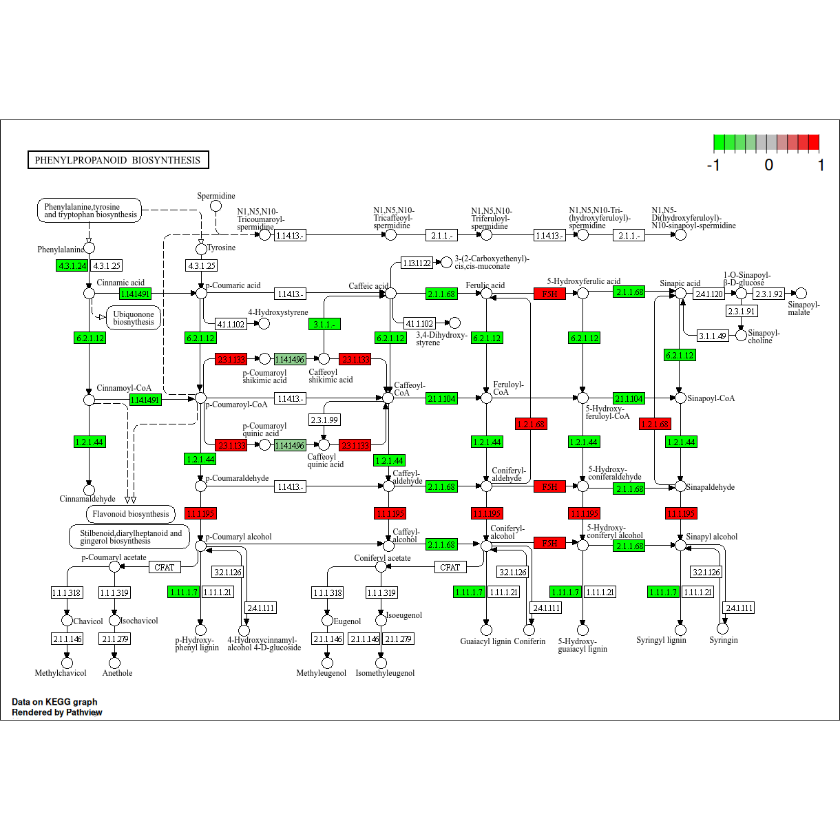

In [2]:
# =====================================================
# GENES DE LA RUTA map00940
# Phenylpropanoid biosynthesis
# =====================================================

library(dplyr)
library(pathview)
library(png)
library(grid)

# =====================================================
# Crear objeto gene_fc_ko
# =====================================================

res_export <- res_df
res_export$gene <- rownames(res_export)

gene_fc_ko <- merge(
  res_export[, c(
    "gene",
    "log2FoldChange",
    "padj"
  )],
  ko_gene,
  by = "gene"
)

colnames(gene_fc_ko)[2] <- "logFC"

# =====================================================
# Cargar InterProScan
# =====================================================

interpro <- read.delim(
  "/home/pazzz/Escritorio/GTF/DE_alstroemeria/anotacionInterpro/pelegrina_pf.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(interpro) <- c(
  "gene","md5","length","db","pfam","pfam_desc",
  "start","end","evalue","status","date",
  "ipr","ipr_desc","go","pathway"
)

interpro$gene <- sub(
  "\\.p[0-9]+$",
  "",
  interpro$gene
)

# =====================================================
# Consolidar anotaciones
# =====================================================

interpro_unique <- interpro %>%
  group_by(gene) %>%
  summarise(
    pfam = paste(unique(na.omit(pfam)), collapse = "; "),
    pfam_desc = paste(unique(na.omit(pfam_desc)), collapse = "; "),
    ipr = paste(unique(na.omit(ipr)), collapse = "; "),
    ipr_desc = paste(unique(na.omit(ipr_desc)), collapse = "; "),
    .groups = "drop"
  )

# =====================================================
# KO presentes en map00940
# =====================================================

ko_00940 <- unique(
  gene2path$KO[
    gene2path$Pathway == "map00940"
  ]
)

cat(
  "Número de KO en map00940:",
  length(ko_00940),
  "\n"
)

# =====================================================
# Genes asociados
# =====================================================

genes_00940 <- gene_fc_ko %>%
  filter(KO %in% ko_00940)

cat(
  "Número de genes asociados:",
  length(unique(genes_00940$gene)),
  "\n"
)

# =====================================================
# Unir con InterPro
# =====================================================

genes_00940_clean <- genes_00940 %>%
  left_join(
    interpro_unique,
    by = "gene"
  ) %>%
  distinct(
    gene,
    KO,
    logFC,
    .keep_all = TRUE
  ) %>%
  arrange(
    desc(abs(logFC))
  )

# =====================================================
# Top genes más regulados
# =====================================================

cat("\n")
cat("========================================\n")
cat("Top genes de Phenylpropanoid biosynthesis\n")
cat("========================================\n")

print(
  genes_00940_clean %>%
    select(
      gene,
      KO,
      logFC,
      pfam_desc,
      ipr_desc
    ) %>%
    head(20)
)

# =====================================================
# Guardar tabla completa
# =====================================================

write.csv(
  genes_00940_clean,
  "Phenylpropanoid_biosynthesis_genes_annotated.csv",
  row.names = FALSE
)
# =====================================================
# Resumen por KO
# =====================================================

ko_summary_00940 <- genes_00940_clean %>%
  group_by(KO) %>%
  summarise(
    n_genes = n(),
    max_logFC = max(logFC, na.rm = TRUE),
    min_logFC = min(logFC, na.rm = TRUE),
    mean_logFC = mean(logFC, na.rm = TRUE),

    pfam_example = paste(
      unique(na.omit(pfam_desc))[1],
      collapse = ""
    ),

    ipr_example = paste(
      unique(na.omit(ipr_desc))[1],
      collapse = ""
    ),

    .groups = "drop"
  ) %>%
  arrange(desc(abs(max_logFC)))

cat("\n")
cat("========================================\n")
cat("RESUMEN POR KO\n")
cat("========================================\n")

print(ko_summary_00940)

# =====================================================
# DEGs importantes
# =====================================================

genes_00940_deg <- genes_00940_clean %>%
  filter(
    abs(logFC) >= 2
  )

cat(
  "\nGenes con |logFC| >= 2:",
  nrow(genes_00940_deg),
  "\n"
)

write.csv(
  genes_00940_deg,
  "Phenylpropanoid_biosynthesis_DEGs.csv",
  row.names = FALSE
)

# =====================================================
# KO presentes
# =====================================================

cat("\n")
cat("KO presentes en map00940:\n")

print(
  sort(
    unique(
      genes_00940_clean$KO
    )
  )
)

# =====================================================
# Mostrar genes más regulados
# =====================================================

cat("\n")
cat("Genes más regulados:\n")

print(
  genes_00940_clean %>%
    select(
      gene,
      KO,
      logFC,
      ipr_desc
    ) %>%
    head(30)
)

# =====================================================
# Crear vector KO -> logFC
# =====================================================

fc_vector_00940 <- genes_00940 %>%
  group_by(KO) %>%
  slice_max(
    abs(logFC),
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup()

fc_vector <- fc_vector_00940$logFC
names(fc_vector) <- fc_vector_00940$KO

# =====================================================
# Descargar pathway KEGG coloreado
# =====================================================

pathview(
  gene.data = fc_vector,
  pathway.id = "00940",
  species = "ko",
  kegg.native = TRUE
)

file.rename(
  "ko00940.pathview.png",
  "ko00940_CSW_vs_ASWO.png"
)

dplyr::count(
  genes_00940_clean,
  KO,
  sort = TRUE
)

# =====================================================
# Mostrar pathway en Jupyter
# =====================================================

img <- readPNG("ko00940_CSW_vs_ASWO.png")

grid.newpage()
grid.raster(img)


In [3]:
# =====================================================
# Funciones observadas por KO
# =====================================================

genes_00940_clean %>%
  group_by(KO) %>%
  summarise(
    funciones = paste(
      unique(ipr_desc[!is.na(ipr_desc)]),
      collapse = " | "
    ),
    .groups = "drop"
  ) %>%
  arrange(KO) %>%
  print(n = Inf)

# A tibble: 13 × 2
   KO     funciones                                                             
   <chr>  <chr>                                                                 
 1 K00083 Cinnamyl alcohol dehydrogenase-like; Alcohol dehydrogenase-like, N-te…
 2 K00430 Plant peroxidase; Haem peroxidase | Haem peroxidase; Plant peroxidase…
 3 K00487 Cytochrome P450; - | -; Cytochrome P450                               
 4 K00588 Class I-like SAM-dependent O-methyltransferase; Cation-dependent O-me…
 5 K01904 AMP-dependent synthetase/ligase domain; -; AMP-binding enzyme, C-term…
 6 K09753 NAD(P)-dependent dehydratase-like; NAD-dependent epimerase/dehydratas…
 7 K09754 -; Cytochrome P450                                                    
 8 K09755 Cytochrome P450; Cytochrome P450 84A | Cytochrome P450 84A; Cytochrom…
 9 K10775 Aromatic amino acid lyase                                             
10 K12355 -; Aldehyde dehydrogenase domain                                      
11 K13065

CANDIDATOS
| Prioridad | KO     | Función                                    |       ID                   |   LOGFC |
| --------- | ------ | ------------------------------------------ |--------------------------- |-------- | 
| 1         | K00083 | Cinnamyl alcohol dehydrogenase             | pelegrina_gene2309_i1      |  2.819  |
| 2         | K13065 | Acyltransferase                            | pelegrina_gene1312472_i5   |  3.36   |
| 3         | K13066 | O-methyltransferase                        | pelegrina_gene1510025_i1   | -3.09   |
| 4         | K09755 | Cytochrome P450 84A                        |                            |         |
| 5         | K18368 | Enzima fenilpropanoide con alta regulación |                            |         |


TRANSPORTADORES ABC

Número de KO en map02010: 20 
Número de genes asociados: 88 

Top genes de ABC TRANSPORTERS
                        gene     KO     logFC
1   pelegrina_gene1913533_i9 K05658 -6.465609
2  pelegrina_gene1754548_i12 K05658 -3.922491
3   pelegrina_gene1048215_i5 K05681  3.774787
4   pelegrina_gene1725472_i3 K08711  3.650311
5    pelegrina_gene831695_i1 K05658 -3.547650
6   pelegrina_gene1318338_i5 K05681  3.370531
7   pelegrina_gene1458236_i3 K05658 -3.354863
8   pelegrina_gene1359860_i1 K02195 -2.286223
9    pelegrina_gene827319_i6 K05658 -2.089908
10  pelegrina_gene1170772_i2 K02471  2.061466
11  pelegrina_gene827315_i11 K05681 -2.042382
12    pelegrina_gene14178_i3 K05658 -1.979751
13  pelegrina_gene1337776_i1 K05658  1.792625
14  pelegrina_gene1481921_i2 K05681  1.724470
15  pelegrina_gene1307388_i4 K05658  1.717515
16  pelegrina_gene1461084_i8 K05658 -1.590617
17  pelegrina_gene1901931_i7 K08711  1.480179
18   pelegrina_gene826206_i1 K08711  1.348257
19      pelegrina_gene702_i7 K0565

Note: Only KEGG ortholog gene ID is supported, make sure it looks like "K01488"!

Note: Mapping via KEGG gene ID (not Entrez) is supported for this species,
it looks like "K01488"!

Info: Working in directory /home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA

Info: Writing image file ko02010.pathview.png



[1] TRUE

KO,n
<chr>,<int>
K05658,33
K08711,18
K05681,15
K02471,5
K02066,3
K02067,3
K02193,2
K02195,2
K05674,2


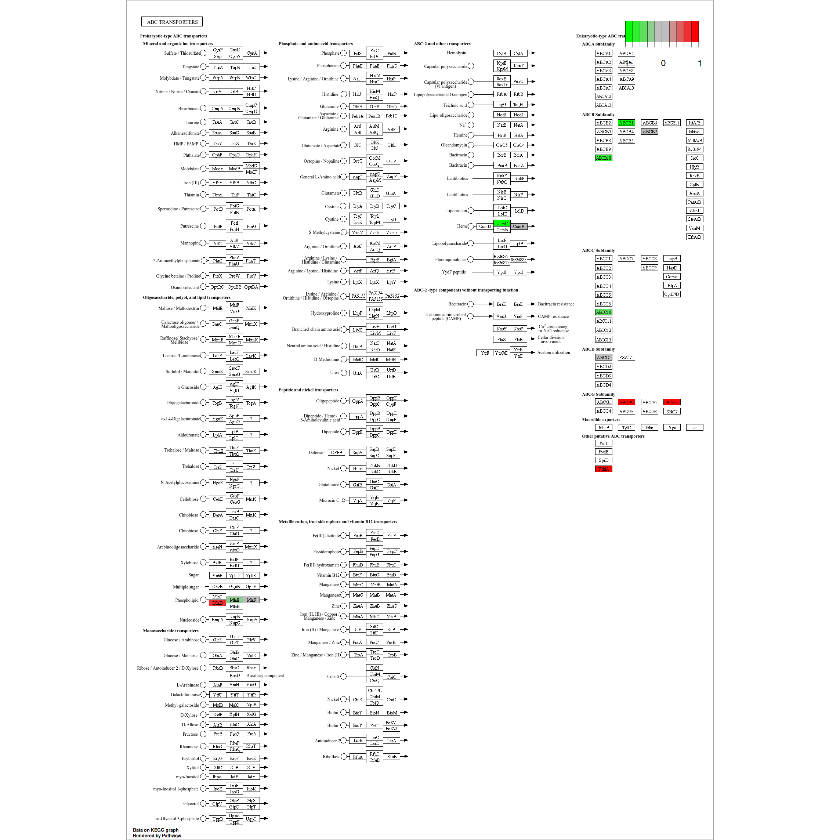

In [9]:
# =====================================================
# GENES DE LA RUTA map02010
# Phenylpropanoid biosynthesis
# =====================================================

library(dplyr)
library(pathview)
library(png)
library(grid)

# =====================================================
# Crear objeto gene_fc_ko
# =====================================================

res_export <- res_df
res_export$gene <- rownames(res_export)

gene_fc_ko <- merge(
  res_export[, c(
    "gene",
    "log2FoldChange",
    "padj"
  )],
  ko_gene,
  by = "gene"
)

colnames(gene_fc_ko)[2] <- "logFC"

# =====================================================
# Cargar InterProScan
# =====================================================

interpro <- read.delim(
  "/home/pazzz/Escritorio/GTF/DE_alstroemeria/anotacionInterpro/pelegrina_pf.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(interpro) <- c(
  "gene","md5","length","db","pfam","pfam_desc",
  "start","end","evalue","status","date",
  "ipr","ipr_desc","go","pathway"
)

interpro$gene <- sub(
  "\\.p[0-9]+$",
  "",
  interpro$gene
)

# =====================================================
# Consolidar anotaciones
# =====================================================

interpro_unique <- interpro %>%
  group_by(gene) %>%
  summarise(
    pfam = paste(unique(na.omit(pfam)), collapse = "; "),
    pfam_desc = paste(unique(na.omit(pfam_desc)), collapse = "; "),
    ipr = paste(unique(na.omit(ipr)), collapse = "; "),
    ipr_desc = paste(unique(na.omit(ipr_desc)), collapse = "; "),
    .groups = "drop"
  )

# =====================================================
# KO presentes en map00940
# =====================================================

ko_02010 <- unique(
  gene2path$KO[
    gene2path$Pathway == "map02010"
  ]
)

cat(
  "Número de KO en map02010:",
  length(ko_02010),
  "\n"
)

# =====================================================
# Genes asociados
# =====================================================

genes_02010 <- gene_fc_ko %>%
  filter(KO %in% ko_02010)

cat(
  "Número de genes asociados:",
  length(unique(genes_02010$gene)),
  "\n"
)

# =====================================================
# Unir con InterPro
# =====================================================

genes_02010_clean <- genes_02010 %>%
  left_join(
    interpro_unique,
    by = "gene"
  ) %>%
  distinct(
    gene,
    KO,
    logFC,
    .keep_all = TRUE
  ) %>%
  arrange(
    desc(abs(logFC))
  )

# =====================================================
# Top genes más regulados
# =====================================================

cat("\n")
cat("========================================\n")
cat("Top genes de ABC TRANSPORTERS\n")
cat("========================================\n")

print(
  genes_02010_clean %>%
    select(
      gene,
      KO,
      logFC,
      pfam_desc,
      ipr_desc
    ) %>%
    head(20)
)

# =====================================================
# Guardar tabla completa
# =====================================================

write.csv(
  genes_02010_clean,
  "ABC_transporters_genes_annotated.csv",
  row.names = FALSE
)
# =====================================================
# Resumen por KO
# =====================================================

ko_summary_02010 <- genes_02010_clean %>%
  group_by(KO) %>%
  summarise(
    n_genes = n(),
    max_logFC = max(logFC, na.rm = TRUE),
    min_logFC = min(logFC, na.rm = TRUE),
    mean_logFC = mean(logFC, na.rm = TRUE),

    pfam_example = paste(
      unique(na.omit(pfam_desc))[1],
      collapse = ""
    ),

    ipr_example = paste(
      unique(na.omit(ipr_desc))[1],
      collapse = ""
    ),

    .groups = "drop"
  ) %>%
  arrange(desc(abs(max_logFC)))

cat("\n")
cat("========================================\n")
cat("RESUMEN POR KO\n")
cat("========================================\n")

print(ko_summary_02010)

# =====================================================
# DEGs importantes
# =====================================================

genes_02010_deg <- genes_02010_clean %>%
  filter(
    abs(logFC) >= 2,
    padj <= 0.05
  ) %>%
  arrange(desc(abs(logFC)))

cat(
  "\nGenes con |logFC| >= 2:",
  nrow(genes_02010_deg),
  "\n"
)

write.csv(
  genes_02010_deg,
  "ABC_transporters_DEGs.csv",
  row.names = FALSE
)

# =====================================================
# KO presentes
# =====================================================

cat("\n")
cat("KO presentes en map02010:\n")

print(
  sort(
    unique(
      genes_02010_clean$KO
    )
  )
)

# =====================================================
# Mostrar genes más regulados
# =====================================================

cat("\n")
cat("Genes más regulados:\n")

print(
  genes_02010_clean %>%
    select(
      gene,
      KO,
      logFC,
      ipr_desc
    ) %>%
    head(30)
)

# =====================================================
# Crear vector KO -> logFC
# =====================================================

fc_vector_02010 <- genes_02010 %>%
  group_by(KO) %>%
  slice_max(
    abs(logFC),
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup()

fc_vector <- fc_vector_02010$logFC
names(fc_vector) <- fc_vector_02010$KO

# =====================================================
# Descargar pathway KEGG coloreado
# =====================================================

pathview(
  gene.data = fc_vector,
  pathway.id = "02010",
  species = "ko",
  kegg.native = TRUE
)

file.rename(
  "ko02010.pathview.png",
  "ko02010_CSW_vs_ASWO.png"
)

dplyr::count(
  genes_02010_clean,
  KO,
  sort = TRUE
)

# =====================================================
# Mostrar pathway en Jupyter
# =====================================================

img <- readPNG("ko02010_CSW_vs_ASWO.png")

grid.newpage()
grid.raster(img)


In [10]:
genes_02010_deg %>%
  select(
    gene,
    KO,
    logFC,
    padj,
    ipr_desc
  )

genes_02010_deg %>%
  count(KO, sort = TRUE)

genes_02010_deg %>%
  group_by(KO) %>%
  summarise(
    n_genes = n(),
    max_logFC = max(abs(logFC)),
    example_function = first(ipr_desc),
    .groups="drop"
  ) %>%
  arrange(desc(max_logFC))

gene,KO,logFC,padj,ipr_desc
<chr>,<chr>,<dbl>,<dbl>,<chr>
pelegrina_gene1913533_i9,K05658,-6.465609,6.131980e-03,"ABC transporter type 1, transmembrane domain; ABC transporter-like, ATP-binding domain; Type 1 protein exporter"
pelegrina_gene1754548_i12,K05658,-3.922491,1.926142e-16,"ABC transporter-like, ATP-binding domain; ABC transporter type 1, transmembrane domain; Type 1 protein exporter"
pelegrina_gene1048215_i5,K05681,3.774787,1.042705e-247,"ATP-binding cassette subfamily G transporters; ABC transporter-like, ATP-binding domain; ABC-2 type transporter, transmembrane domain"
pelegrina_gene1725472_i3,K08711,3.650311,4.089364e-95,"Pleiotropic ABC efflux transporter, N-terminal domain; -; ABC transporter family G domain; ABC-2 type transporter, transmembrane domain; Plant PDR ABC transporter associated; ABC transporter-like, ATP-binding domain"
pelegrina_gene831695_i1,K05658,-3.547650,3.460888e-07,"ABC transporter-like, ATP-binding domain; ABC transporter type 1, transmembrane domain; -"
pelegrina_gene827319_i6,K05658,-2.089908,1.646890e-06,"ABC transporter type 1, transmembrane domain; ABC transporter-like, ATP-binding domain; Type 1 protein exporter"
pelegrina_gene1170772_i2,K02471,2.061466,2.343212e-02,"ABC transporter-like, ATP-binding domain; ATP-binding cassette sub-family D; ABC transporter type 1, transmembrane domain"
pelegrina_gene827315_i11,K05681,-2.042382,9.296884e-06,"ABC-2 type transporter, transmembrane domain; ABC transporter-like, ATP-binding domain; ABC transporter family G domain; ATP-binding cassette subfamily G transporters"


KO,n
<chr>,<int>
K05658,4
K05681,2
K02471,1
K08711,1


KO,n_genes,max_logFC,example_function
<chr>,<int>,<dbl>,<chr>
K05658,4,6.465609,"ABC transporter type 1, transmembrane domain; ABC transporter-like, ATP-binding domain; Type 1 protein exporter"
K05681,2,3.774787,"ATP-binding cassette subfamily G transporters; ABC transporter-like, ATP-binding domain; ABC-2 type transporter, transmembrane domain"
K08711,1,3.650311,"Pleiotropic ABC efflux transporter, N-terminal domain; -; ABC transporter family G domain; ABC-2 type transporter, transmembrane domain; Plant PDR ABC transporter associated; ABC transporter-like, ATP-binding domain"
K02471,1,2.061466,"ABC transporter-like, ATP-binding domain; ATP-binding cassette sub-family D; ABC transporter type 1, transmembrane domain"


| Prioridad | Transcrito                | KO     | Función                                             |  logFC |        padj |
| --------- | ------------------------- | ------ | --------------------------------------------------- | -----: | ----------: |
| 1         | pelegrina_gene1725472_i3  | K08711 | Pleiotropic ABC efflux transporter (PDR/ABCG)       |  3.650 |  4.09×10⁻⁹⁵ |
| 2         | pelegrina_gene1048215_i5  | K05681 | ATP-binding cassette subfamily G transporter (ABCG) |  3.775 | 1.04×10⁻²⁴⁷ |
| 3         | pelegrina_gene827315_i11  | K05681 | ATP-binding cassette subfamily G transporter (ABCG) | -2.042 |   9.30×10⁻⁶ |
| 4         | pelegrina_gene1913533_i9  | K05658 | Type 1 protein exporter ABC transporter             | -6.466 |   6.13×10⁻³ |
| 5         | pelegrina_gene1754548_i12 | K05658 | Type 1 protein exporter ABC transporter             | -3.922 |  1.93×10⁻¹⁶ |
| 6         | pelegrina_gene831695_i1   | K05658 | ABC transporter type 1                              | -3.548 |   3.46×10⁻⁷ |
| 7         | pelegrina_gene827319_i6   | K05658 | Type 1 protein exporter ABC transporter             | -2.090 |   1.65×10⁻⁶ |
| 8         | pelegrina_gene1170772_i2  | K02471 | ABC transporter subfamily D (ABCD)                  |  2.061 |   2.34×10⁻² |


Linking to ImageMagick 6.9.12.98
Enabled features: fontconfig, freetype, fftw, heic, lcms, pango, raw, webp, x11
Disabled features: cairo, ghostscript, rsvg

Using 12 threads



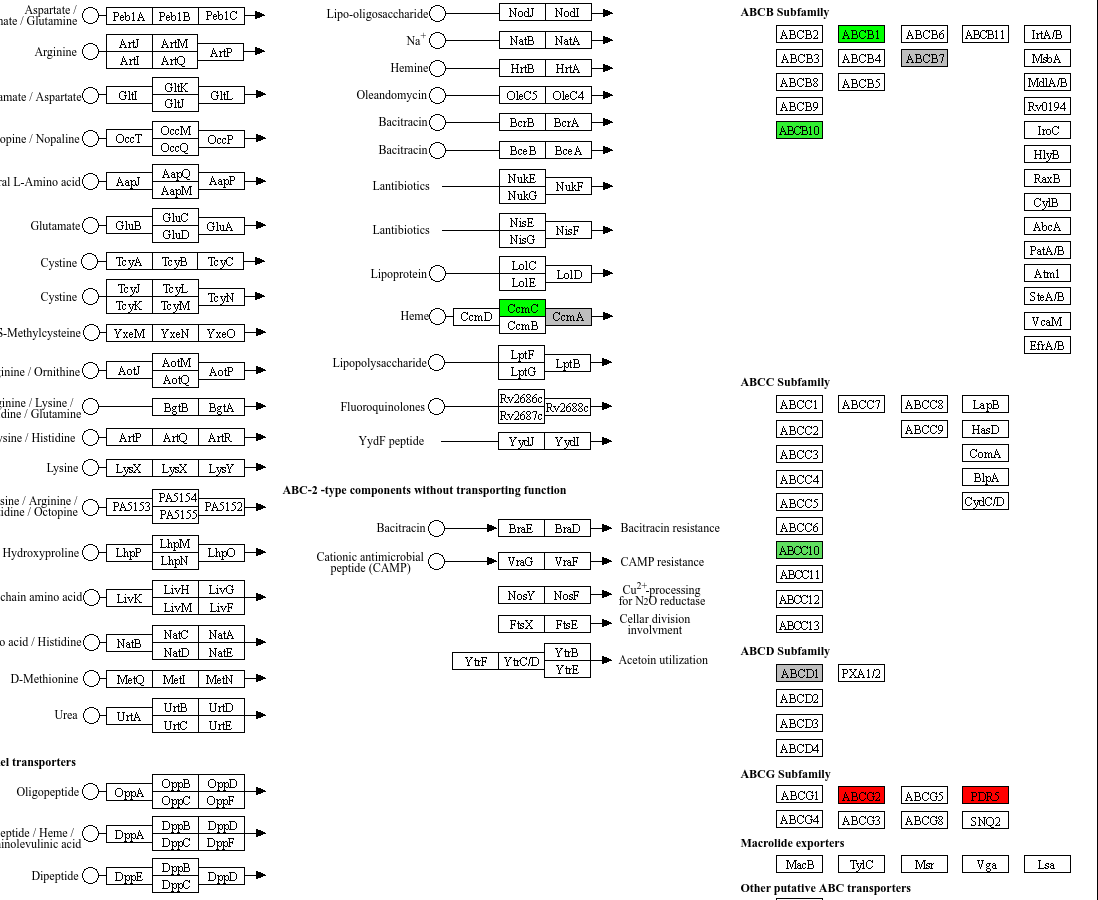

# A tibble: 1 × 7
  format width height colorspace matte filesize density
  <chr>  <int>  <int> <chr>      <lgl>    <int> <chr>  
1 PNG     1098    900 sRGB       FALSE        0 118x118

In [11]:
library(magick)

img <- image_read("ko02010_CSW_vs_ASWO.png")

img_crop <- image_crop(
  img,
  geometry = "1400x900+500+300"
)

image_write(
  img_crop,
  "ko02010_CSW_vs_ASWO_crop.png"
)

img_crop

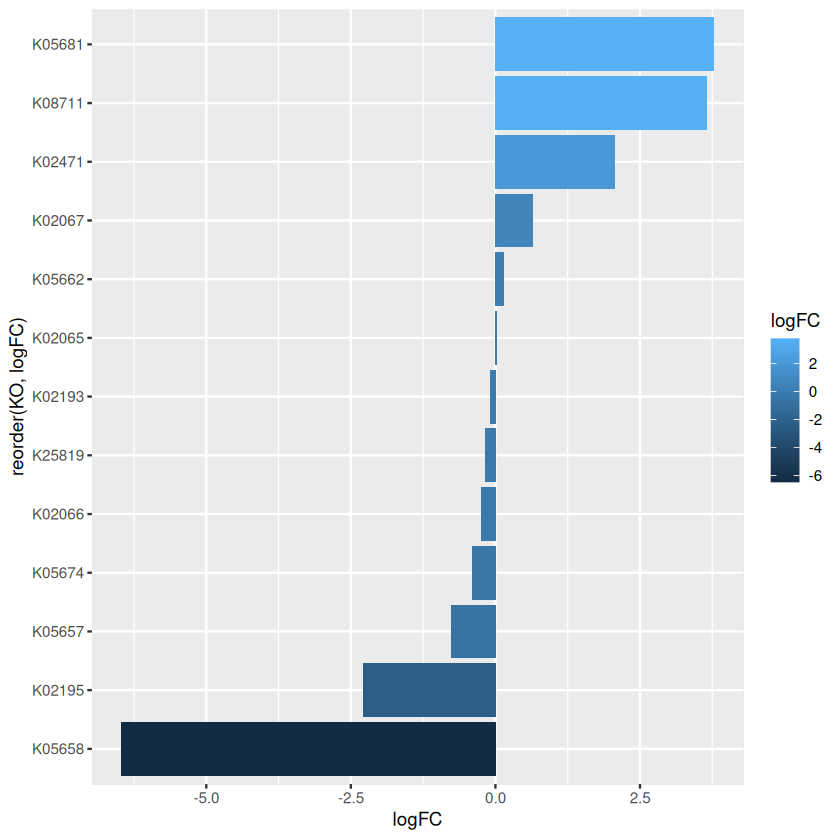

In [12]:
library(ggplot2)

top_ko <- genes_02010_clean %>%
  group_by(KO) %>%
  slice_max(abs(logFC), n=1)

ggplot(
  top_ko,
  aes(
    reorder(KO, logFC),
    logFC,
    fill = logFC
  )
) +
  geom_col() +
  coord_flip()

| KO         | Interpretación             |
| ---------- | -------------------------- |
| **K08711** | PDR ABC transporter (ABCG) |
| **K05681** | ABCG transporter           |
| **K05658** | ABCB transporter           |


In [13]:
library(ggplot2)
library(dplyr)
library(stringr)

# 1. Filtrar y preparar los datos directamente en un data.frame
plot_data <- as.data.frame(kegg_enrich) %>%
  # CORREGIDO: Se eliminó el espacio en blanco antes de "map00073"
  filter(ID %in% c("map00940", "map00073", "map00062", "map02010")) %>%
  # Limpiar el nombre de las rutas (ej. quitar " - Organism name" si lo tuviera)
  mutate(Description = str_replace(Description, " - .*$", "")) %>%
  # Asegurar que el orden de las barras dependa de la significancia (p.adjust)
  mutate(Description = reorder(Description, Count))

# 2. Construcción del gráfico con ggplot2
p <- ggplot(plot_data, aes(x = Count, y = Description, fill = p.adjust)) +
  # CORREGIDO: Se cambió 'size' por 'linewidth' para evitar warnings de ggplot2
  geom_col(width = 0.65, color = "black", linewidth = 0.25) +
  
  # Paleta de colores plasma con transformación logarítmica para balancear los p-values
  scale_fill_viridis_c(
    option = "plasma", 
    direction = -1,
    name = expression(italic("p") * "-adjust"),
    trans = "log10", # Recomendado para mejorar el contraste entre p-values distantes
    guide = guide_colorbar(ticks.colour = "black", frame.colour = "black")
  ) +
  
  # Etiquetas claras y formales
  labs(
    x = "Number of Genes (Count)",
    y = "KEGG Pathway",
    title = "Enrichment of Pigment-Related Pathways",
    subtitle = "Significantly enriched categories based on differential expression"
  ) +
  
  # Aplicar un tema minimalista y limpio
  theme_minimal(base_size = 12, base_family = "sans") + 
  theme(
    # Eliminar líneas de cuadrícula secundarias y del eje Y para limpiar el fondo
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_line(color = "gray92", linetype = "dashed"),
    # Ajustes de los ejes (línea del eje Y sólida)
    axis.line.y = element_line(color = "black", linewidth = 0.5),
    axis.ticks.y = element_line(color = "black"),
    # Formato de textos
    axis.text = element_text(color = "black", face = "plain"),
    axis.title = element_text(color = "black", face = "bold"),
    plot.title = element_text(face = "bold", size = 14, margin = margin(b = 5)),
    plot.subtitle = element_text(color = "gray30", size = 10, margin = margin(b = 15)),
    # Ajustes de la leyenda
    legend.position = "right",
    legend.title = element_text(size = 10, face = "bold"),
    legend.background = element_blank()
  )

# Guardamos la versión PNG lista para el manuscrito
ggsave(
  "KEGG_Barplot_CSW_ASWO_Publication.png",
  plot = p,
  width = 8,
  height = 5,
  dpi = 300
)

In [14]:
library(KEGGREST)

kos <- unique(genes_02010_clean$KO)

ko_ec <- lapply(kos, function(k){

  info <- keggGet(k)[[1]]

  data.frame(
    KO = k,
    EC = paste(info$ENZYME, collapse=";"),
    NAME = info$NAME[1]
  )

})

ko_ec <- do.call(rbind, ko_ec)
ko_ec

KO,EC,NAME
<chr>,<chr>,<chr>
K05658,,"ATP-binding cassette, subfamily B (MDR/TAP), member 1 [EC:7.6.2.2]"
K05681,,"ATP-binding cassette, subfamily G (WHITE), member 2"
K08711,,"ATP-binding cassette, subfamily G (WHITE), member 2, PDR"
K02195,,heme exporter protein C
K02471,,vitamin B12/bleomycin/antimicrobial peptide transport system ATP-binding/permease protein
K05657,,"ATP-binding cassette, subfamily B (MDR/TAP), member 10"
K02067,,phospholipid/cholesterol/gamma-HCH transport system substrate-binding protein
K05674,,"ATP-binding cassette, subfamily C (CFTR/MRP), member 10"
K02066,,phospholipid/cholesterol/gamma-HCH transport system permease protein


NUEVO VOLCANO PLOT CON LOS TRANSCRITOS ASOCIADOS A PIGMENTOS DESTACADOS

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message in plot_theme(plot):
“The `plot.subtitle.position` theme element is not defined in the element
hierarchy.”
Warning message:
“Removed 47 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in plot_theme(plot):
“The `plot.subtitle.position` theme element is not defined in the element
hierarchy.”
Warning message:
“Removed 47 rows containing missing values or values outside the scale range
(`geom_point()`).”


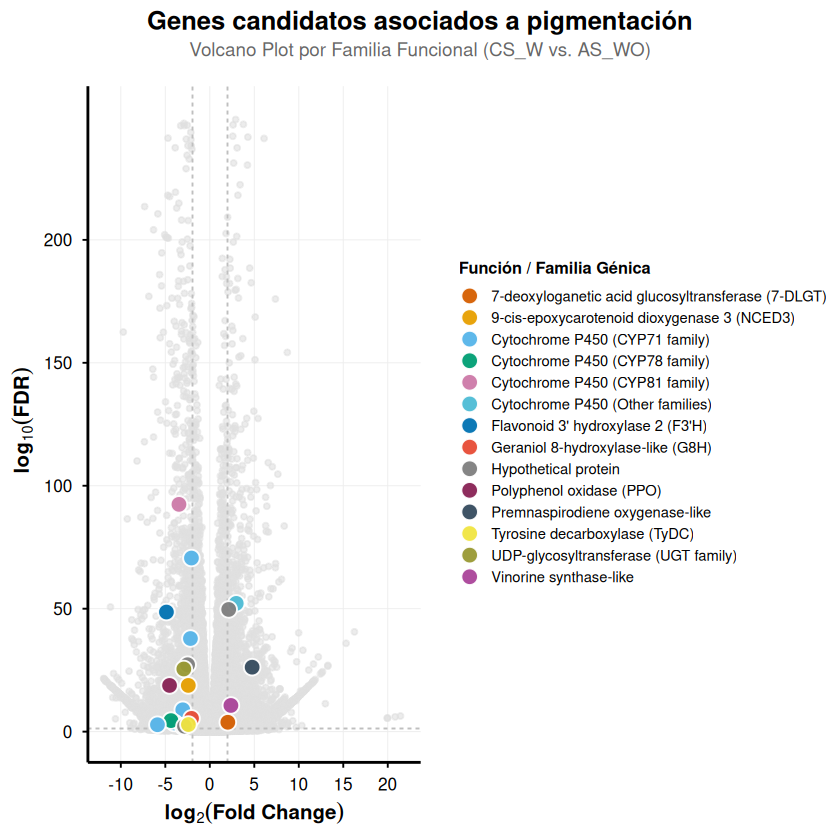

In [ ]:
library(dplyr)
library(ggplot2)

#=========================================================
# 1. Nueva Tabla de Descripciones Funcionales Limpias (CS_W vs AS_WO)
#=========================================================
descripciones_completa <- data.frame(
  gene = c(
    "pelegrina_gene1170725_i2", "pelegrina_gene162036_i1", "pelegrina_gene1037623_i3",
    "pelegrina_gene1904850_i1", "pelegrina_gene1748183_i1", "pelegrina_gene1463574_i8",
    "pelegrina_gene843791_i2", "pelegrina_gene1452632_i3", "pelegrina_gene1313581_i1",
    "pelegrina_gene1478299_i1", "pelegrina_gene1172636_i8", "pelegrina_gene1412731_i1",
    "pelegrina_gene1524_i4", "pelegrina_gene1911193_i2", "pelegrina_gene846247_i2",  
    "pelegrina_gene835130_i1", "pelegrina_gene15924_i6", "pelegrina_gene1047824_i3",
    "pelegrina_gene1061014_i1", "pelegrina_gene1314155_i6", "pelegrina_gene1317880_i1"
  ),
  family = c(
    "UDP-glycosyltransferase (UGT family)",
    "Cytochrome P450 (CYP71 family)",
    "Polyphenol oxidase (PPO)",
    "Vinorine synthase-like",
    "Tyrosine decarboxylase (TyDC)",
    "Hypothetical protein",
    "7-deoxyloganetic acid glucosyltransferase (7-DLGT)",
    "Cytochrome P450 (CYP71 family)",
    "Flavonoid 3' hydroxylase 2 (F3'H)",
    "Cytochrome P450 (CYP78 family)",
    "Cytochrome P450 (Other families)",
    "Cytochrome P450 (CYP71 family)",
    "Geraniol 8-hydroxylase-like (G8H)",
    "Cytochrome P450 (CYP71 family)",
    "Cytochrome P450 (CYP81 family)",
    "Premnaspirodiene oxygenase-like",
    "Hypothetical protein",
    "9-cis-epoxycarotenoid dioxygenase 3 (NCED3)",
    "Hypothetical protein",
    "Cytochrome P450 (CYP71 family)",
    "Hypothetical protein"
  ),
  stringsAsFactors = FALSE
)

#=========================================================
# 2. Preparar datos (Heredando lfc_cutoff y padj_cutoff)
#=========================================================
res_plot <- res_df %>%
  filter(!is.na(padj), padj > 0) %>%
  mutate(
    gene = rownames(.),
    regulation = case_when(
      padj < padj_cutoff & log2FoldChange >= lfc_cutoff ~ "Sobreexpresado",
      padj < padj_cutoff & log2FoldChange <= -lfc_cutoff ~ "Subexpresado",
      TRUE ~ "No significativo"
    )
  )

# Unir con las nuevas descripciones funcionales
res_plot <- left_join(res_plot, descripciones_completa, by="gene")

# Separar los datos en dos capas: fondo (gris) y destacados (color)
genes_fondo <- res_plot %>% filter(is.na(family))
genes_color <- res_plot %>% filter(!is.na(family))

#=========================================================
# 3. Nueva Paleta de Colores Estandarizada
#=========================================================
colores_familias <- c(
  "7-deoxyloganetic acid glucosyltransferase (7-DLGT)" = "#D55E00",
  "Cytochrome P450 (CYP71 family)"                     = "#56B4E9",
  "Cytochrome P450 (CYP78 family)"                     = "#009E73",
  "Cytochrome P450 (CYP81 family)"                     = "#CC79A7",
  "Cytochrome P450 (Other families)"                   = "#4DBBD5FF",
  "Flavonoid 3' hydroxylase 2 (F3'H)"                  = "#0072B2",
  "Geraniol 8-hydroxylase-like (G8H)"                  = "#E64B35FF",
  "Hypothetical protein"                               = "#7F7F7F",
  "9-cis-epoxycarotenoid dioxygenase 3 (NCED3)"        = "#E69F00",
  "Polyphenol oxidase (PPO)"                           = "#882255",
  "Premnaspirodiene oxygenase-like"                    = "#354B5E",
  "Tyrosine decarboxylase (TyDC)"                      = "#F0E442",
  "UDP-glycosyltransferase (UGT family)"               = "#999933",
  "Vinorine synthase-like"                             = "#AA4499"
)

#=========================================================
# 4. Volcano Plot con Proporciones Optimizadas
#=========================================================
p1_proportional <- ggplot() +

  geom_point(
    data = genes_fondo,
    aes(x = log2FoldChange, y = -log10(padj)),
    color = "grey88",
    size = 1.0,
    alpha = 0.6
  ) +

  geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dashed", color = "grey75", size = 0.4) +
  geom_hline(yintercept = -log10(padj_cutoff), linetype = "dashed", color = "grey75", size = 0.4) +

  geom_point(
    data = genes_color,
    aes(x = log2FoldChange, y = -log10(padj), fill = family),
    shape = 21,         
    color = "white",    
    stroke = 0.6,       
    size = 4.0,         
    alpha = 0.95
  ) +

  scale_fill_manual(
    name = "Función / Familia Génica",
    values = colores_familias
  ) +

  ##  ejes y títulos de la nueva comparación
  labs(
    title = "Genes candidatos asociados a pigmentación",
    subtitle = "Volcano Plot por Familia Funcional (CS_W vs. AS_WO)",
    x = expression(bold(log[2]("Fold Change"))),
    y = expression(bold(-log[10]("FDR")))
  ) +

  scale_x_continuous(limits = c(-12, 22), breaks = seq(-10, 20, by = 5)) +
  scale_y_continuous(limits = c(0, 250), breaks = seq(0, 200, by = 50)) +

  theme_minimal(base_size = 13) +
  theme(
    plot.title.position = "plot",    
    plot.subtitle.position = "plot", 
    plot.title = element_text(face = "bold", hjust = 0.5, size = 15, color = "black"),
    plot.subtitle = element_text(hjust = 0.5, size = 11, color = "grey40", margin = margin(t = -3, b = 15)),
    
    # Ejes
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 10, color = "black"),
    axis.line = element_line(size = 0.6, color = "black"),
    axis.ticks = element_line(size = 0.4, color = "black"),

    # Leyenda lateral balanceada
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 9.5), 
    legend.text = element_text(size = 8.5),                 
    legend.key.size = unit(0.9, "lines"), 
    legend.margin = margin(0, 0, 0, 10),
    
    # Cuadricula
    panel.grid.major = element_line(size = 0.2, color = "grey93"),
    panel.grid.minor = element_blank()
  )

#=========================================================
# 5. Guardar gráfico con dimensiones profesionales
#=========================================================
ggsave(
  filename = "Volcano_CSW_vs_ASWO_Families.png",
  plot = p1_proportional,
  width = 11.5,     
  height = 7.0,
  dpi = 300,
  bg = "white"
)

print(p1_proportional)